<a href="https://colab.research.google.com/github/nyee88/tvam_resin_mini/blob/main/notebooks/01_working_curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- Bootstrap: make paths work in Colab ---
import os, pathlib, subprocess

REPO_URL = "https://github.com/nyee88/tvam_resin_mini.git"  # your repo URL
REPO_DIR = "tvam_resin_mini"

if not pathlib.Path(REPO_DIR).exists():
    subprocess.run(["git", "clone", REPO_URL], check=True)

os.chdir(REPO_DIR)
print("CWD:", os.getcwd())
print("CSV exists?", pathlib.Path("data/ec_dp_405nm.csv").exists())


CWD: /content/tvam_resin_mini
CSV exists? True


,resin_or_source,Ec_mJ_cm2,Dp_um,wavelength_nm,notes
0,ExampleResin_A,6.5,120,405,vendor or paper link
1,ExampleResin_B,4.8,85,405,vendor or paper link
2,ExampleResin_C,10.2,200,405,vendor or paper link
3,Fast_Clear_Gen1,4.0,70,405,low Ec but shallow Dp
4,Fast_Clear_Gen2,3.2,90,405,improved clear formulation
5,Tough_Amber,8.0,150,405,tough resin deeper penetration
6,Black_HiRes,7.5,60,405,pigmented low Dp
7,Dental_Model,5.5,110,405,balanced Ec/Dp
8,Castable_WaxLike,9.0,80,405,high Ec more picky
9,Ultra_Clear_Deep,6.0,220,405,depth-optimized


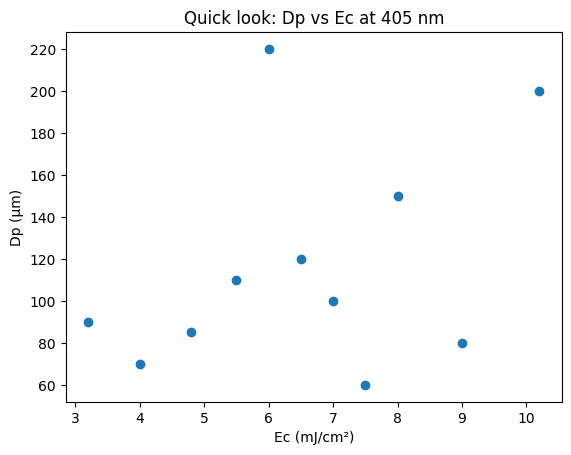

,resin_or_source,Ec_mJ_cm2,Dp_um,E_needed_mJcm2_for_100um
0,ExampleResin_A,6.5,120,14.956343
1,ExampleResin_B,4.8,85,15.565960
2,ExampleResin_C,10.2,200,16.816957
3,Fast_Clear_Gen1,4.0,70,16.690936
4,Fast_Clear_Gen2,3.2,90,9.720742
5,Tough_Amber,8.0,150,15.581872
6,Black_HiRes,7.5,60,39.708675
7,Dental_Model,5.5,110,13.651358
8,Castable_WaxLike,9.0,80,31.413087
9,Ultra_Clear_Deep,6.0,220,9.452743


In [2]:
# --- Install minimal deps (fast) ---
!pip -q install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1) Load your tiny Ec/Dp table ---
csv_path = "data/ec_dp_405nm.csv"  # when saved back to GitHub, this relative path will work
df = pd.read_csv(csv_path, comment='#')

# Basic sanity checks
required = ["resin_or_source", "Ec_mJ_cm2", "Dp_um", "wavelength_nm"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"
assert (df["wavelength_nm"] == 405).all(), "Keep wavelength at 405 nm for now."

display(df)

# --- 2) Quick plot: Dp vs Ec (both matter for exposure) ---
plt.figure()
plt.scatter(df["Ec_mJ_cm2"], df["Dp_um"])
plt.xlabel("Ec (mJ/cm²)")
plt.ylabel("Dp (µm)")
plt.title("Quick look: Dp vs Ec at 405 nm")
plt.show()

# --- 3) Tiny demo: dose needed for a target cured depth ---
# Jacobs working-curve: Cd = Dp * ln(E / Ec)  -> E = Ec * exp(Cd/Dp)
target_Cd_um = 100  # e.g., aim to fully cure ~100 µm
df["E_needed_mJcm2_for_100um"] = df.apply(
    lambda r: r["Ec_mJ_cm2"] * (2.718281828 ** (target_Cd_um / r["Dp_um"])),
    axis=1
)
display(df[["resin_or_source", "Ec_mJ_cm2", "Dp_um", "E_needed_mJcm2_for_100um"]])


In [3]:
import numpy as np

for L_um in [50, 100, 150]:
    E_needed = df["Ec_mJ_cm2"] * np.exp(L_um / df["Dp_um"])
    print(f"\nLayer L = {L_um} µm  (lower is better)")
    display(df.assign(E_for_L=E_needed)[["resin_or_source","E_for_L"]]
              .sort_values("E_for_L"))



Layer L = 50 µm  (lower is better)


,resin_or_source,E_for_L
4,Fast_Clear_Gen2,5.577309
9,Ultra_Clear_Deep,7.531033
3,Fast_Clear_Gen1,8.170908
1,ExampleResin_B,8.643877
7,Dental_Model,8.665014
0,ExampleResin_A,9.859829
5,Tough_Amber,11.164899
10,Budget_Generic,11.541049
2,ExampleResin_C,13.097059
8,Castable_WaxLike,16.814214



Layer L = 100 µm  (lower is better)


,resin_or_source,E_for_L
9,Ultra_Clear_Deep,9.452743
4,Fast_Clear_Gen2,9.720742
7,Dental_Model,13.651358
0,ExampleResin_A,14.956343
1,ExampleResin_B,15.565960
5,Tough_Amber,15.581872
3,Fast_Clear_Gen1,16.690936
2,ExampleResin_C,16.816957
10,Budget_Generic,19.027973
8,Castable_WaxLike,31.413087



Layer L = 150 µm  (lower is better)


,resin_or_source,E_for_L
9,Ultra_Clear_Deep,11.864819
4,Fast_Clear_Gen2,16.942368
7,Dental_Model,21.507129
2,ExampleResin_C,21.593400
5,Tough_Amber,21.746255
0,ExampleResin_A,22.687229
1,ExampleResin_B,28.031302
10,Budget_Generic,31.371823
3,Fast_Clear_Gen1,34.095026
8,Castable_WaxLike,58.687372


In [4]:
# --- Method A: Learn alpha (two points per resin) and APPLY IT GLOBALLY ---
#
import numpy as np
import pandas as pd

# Assumes you already have df with columns: resin_or_source, Ec_mJ_cm2, Dp_um
# df.head()

# ==== 1) Config: job + temps ====
T0_C       = 23.0   # reference temperature for the vendor Ec in df (assume 23°C)
T_today    = 25.0   # <-- set today's measured temperature
I_mWcm2    = 5.0    # irradiance at resin plane (mW/cm²)
L_um       = 100    # target cured depth (≈ layer thickness)
safety     = 1.15   # small cushion

# ==== 2) Minimal calibration data: Ec at two temps per resin ====
# Replace these with your measured (or synthetic) pairs.
ec_pairs = pd.DataFrame({
    "resin_or_source": ["ExampleResin_A","ExampleResin_B","ExampleResin_C"],
    "T1_C":            [22.0, 22.0, 22.0],
    "Ec1_mJcm2":       [6.8,  5.0, 10.5],   # Ec measured at T1
    "T2_C":            [26.0, 26.0, 26.0],
    "Ec2_mJcm2":       [6.4,  4.7, 10.0],   # Ec measured at T2
})

# ==== 3) Per-resin alpha from two points: alpha = d(ln Ec)/dT ====
dT = ec_pairs["T2_C"] - ec_pairs["T1_C"]
ec_pairs["alpha_per_C"] = (np.log(ec_pairs["Ec2_mJcm2"]) - np.log(ec_pairs["Ec1_mJcm2"])) / dT

# (Optional sanity) show per-resin α
display(ec_pairs[["resin_or_source","alpha_per_C"]])

# ==== 4) Choose a global alpha (simple mean of per-resin) ====
alpha_global = ec_pairs["alpha_per_C"].mean()
print(f"Global alpha (mean): {alpha_global:.4f} per °C  (~{100*alpha_global:.1f}%/°C)")

# ==== 5) Temperature-adjust Ec to today's T and compute dose/time ====
# Assume df['Ec_mJ_cm2'] is defined at T0_C. Adjust to today's T:
Ec_T = df["Ec_mJ_cm2"] * np.exp(alpha_global * (T_today - T0_C))

# Dose for target layer with safety, then time = dose / I
E_star_T = safety * Ec_T * np.exp(L_um / df["Dp_um"])
t_star_T = E_star_T / I_mWcm2

result = df.assign(
    Ec_at_T=Ec_T,
    E_star_mJcm2=E_star_T,
    t_star_s=t_star_T
)[["resin_or_source","Ec_at_T","E_star_mJcm2","t_star_s"]].sort_values("t_star_s")

display(result)

# alpha is the percent Ec decreases by degree centigrade. we can calculate a universal alpha by averaging all, for unknown resins.
# E star is simply the energy required to cure 100 um depth (arbitrary)
# t_star is  E_star/5_mWcm^2 (we arbitrarily picked the irradiance)



,resin_or_source,alpha_per_C
0,ExampleResin_A,-0.015156
1,ExampleResin_B,-0.015469
2,ExampleResin_C,-0.012198


Global alpha (mean): -0.0143 per °C  (~-1.4%/°C)


,resin_or_source,Ec_at_T,E_star_mJcm2,t_star_s
9,Ultra_Clear_Deep,5.831132,10.564703,2.112941
4,Fast_Clear_Gen2,3.109937,10.864227,2.172845
7,Dental_Model,5.345204,15.257216,3.051443
0,ExampleResin_A,6.317059,16.715712,3.343142
1,ExampleResin_B,4.664905,17.397040,3.479408
5,Tough_Amber,7.774842,17.414824,3.482965
3,Fast_Clear_Gen1,3.887421,18.654350,3.730870
2,ExampleResin_C,9.912924,18.795196,3.759039
10,Budget_Generic,6.802987,21.266301,4.253260
8,Castable_WaxLike,8.746698,35.108321,7.021664


In [5]:
import numpy as np
import pandas as pd

def plan_exposures(
    df_resins,
    L_um=100,
    I_mWcm2=5.0,
    safety=1.15,
    T_today=25.0,
    T_ref=23.0,
    alpha_global=None,
    use_temp_correction=True,
):
    """
    Tiny helper that wraps what you're already doing:

    Inputs:
      - df_resins: DataFrame with Ec_mJ_cm2, Dp_um, resin_or_source
      - L_um:      target cured depth / layer thickness (µm)
      - I_mWcm2:   irradiance (mW/cm²)
      - safety:    multiplier on top of Jacobs
      - T_today:   actual temperature
      - T_ref:     reference temp for Ec values
      - alpha_global: d(ln Ec)/dT. If None, try ec_pairs; else fallback.
      - use_temp_correction: toggle temperature adjustment on/off.

    Output:
      - DataFrame with Ec_effective, E*, t*, sorted fastest → slowest.
    """
    df = df_resins.copy()

    # 1) Decide alpha_global
    if use_temp_correction:
        if alpha_global is None:
            # If you already computed ec_pairs above, reuse it.
            if "ec_pairs" in globals() and "alpha_per_C" in ec_pairs.columns:
                alpha_global = ec_pairs["alpha_per_C"].mean()
            else:
                # fallback: the ~-1.4%/°C you just got
                alpha_global = -0.0143

        # 2) Temperature-adjusted Ec
        Ec_effective = df["Ec_mJ_cm2"] * np.exp(alpha_global * (T_today - T_ref))
    else:
        Ec_effective = df["Ec_mJ_cm2"]

    # 3) Jacobs + safety: E* and t*
    E_star = safety * Ec_effective * np.exp(L_um / df["Dp_um"])
    t_star = E_star / I_mWcm2

    out = df.assign(
        Ec_effective_mJ_cm2=Ec_effective,
        E_star_mJcm2=E_star,
        t_star_s=t_star
    ).sort_values("t_star_s")

    return out[[
        "resin_or_source",
        "Ec_effective_mJ_cm2",
        "Dp_um",
        "Ec_effective_mJ_cm2",
        "E_star_mJcm2",
        "t_star_s"
    ]]


In [8]:
# test with exactly the same values as before - sanity check. Should output the same table as before.

# Quick test of our new planner function: given a planned job (layer thickness, light intensity, safety factor, temperature),
# it uses each resin’s Ec and Dp to calculate a recommended dose (E*) and exposure time (t*), then shows a table of all resins
# ranked by speed so we can sanity-check that the numbers and ordering look sensible before using it for synthetic data/ML.


plans_100um = plan_exposures(df, L_um=100, I_mWcm2=5.0, safety=1.15,
                             T_today=25.0, T_ref=23.0, use_temp_correction=True)
display(plans_100um)


,resin_or_source,Ec_effective_mJ_cm2,Dp_um,Ec_effective_mJ_cm2,E_star_mJcm2,t_star_s
9,Ultra_Clear_Deep,5.831132,220,5.831132,10.564703,2.112941
4,Fast_Clear_Gen2,3.109937,90,3.109937,10.864227,2.172845
7,Dental_Model,5.345204,110,5.345204,15.257216,3.051443
0,ExampleResin_A,6.317059,120,6.317059,16.715712,3.343142
1,ExampleResin_B,4.664905,85,4.664905,17.397040,3.479408
5,Tough_Amber,7.774842,150,7.774842,17.414824,3.482965
3,Fast_Clear_Gen1,3.887421,70,3.887421,18.654350,3.730870
2,ExampleResin_C,9.912924,200,9.912924,18.795196,3.759039
10,Budget_Generic,6.802987,100,6.802987,21.266301,4.253260
8,Castable_WaxLike,8.746698,80,8.746698,35.108321,7.021664


In [9]:
for L in [50, 100, 150]:
    print(f"\n=== Target layer: {L} µm ===")
    display(plan_exposures(df, L_um=L, I_mWcm2=5.0, safety=1.15,
                           T_today=25.0, T_ref=23.0).head(5))

    # Plan three example jobs (50, 100, 150 µm): for each thickness we call the same planner,
# overriding L_um with that value to see how recommended E* and t* change across layer heights.




=== Target layer: 50 µm ===


,resin_or_source,Ec_effective_mJ_cm2,Dp_um,Ec_effective_mJ_cm2,E_star_mJcm2,t_star_s
4,Fast_Clear_Gen2,3.109937,90,3.109937,6.233388,1.246678
9,Ultra_Clear_Deep,5.831132,220,5.831132,8.416935,1.683387
3,Fast_Clear_Gen1,3.887421,70,3.887421,9.132081,1.826416
1,ExampleResin_B,4.664905,85,4.664905,9.660687,1.932137
7,Dental_Model,5.345204,110,5.345204,9.684311,1.936862



=== Target layer: 100 µm ===


,resin_or_source,Ec_effective_mJ_cm2,Dp_um,Ec_effective_mJ_cm2,E_star_mJcm2,t_star_s
9,Ultra_Clear_Deep,5.831132,220,5.831132,10.564703,2.112941
4,Fast_Clear_Gen2,3.109937,90,3.109937,10.864227,2.172845
7,Dental_Model,5.345204,110,5.345204,15.257216,3.051443
0,ExampleResin_A,6.317059,120,6.317059,16.715712,3.343142
1,ExampleResin_B,4.664905,85,4.664905,17.397040,3.479408



=== Target layer: 150 µm ===


,resin_or_source,Ec_effective_mJ_cm2,Dp_um,Ec_effective_mJ_cm2,E_star_mJcm2,t_star_s
9,Ultra_Clear_Deep,5.831132,220,5.831132,13.260520,2.652104
4,Fast_Clear_Gen2,3.109937,90,3.109937,18.935360,3.787072
7,Dental_Model,5.345204,110,5.345204,24.037090,4.807418
2,ExampleResin_C,9.912924,200,9.912924,24.133509,4.826702
5,Tough_Amber,7.774842,150,7.774842,24.304344,4.860869


## Step 2 – From physics planner to synthetic experiments

##Now that we have a planner that takes a planned job (layer thickness, intensity, safety factor, temperature)
and returns recommended dose/time (E\*) for each resin, we’ll pretend to run a small print study:
for several resins and layer thicknesses, we will try exposure doses around E\*, mark each attempt as
pass/fail, and use that as a toy dataset for a simple ML model. The key idea:
**Jacobs + Ec/Dp gives us E\***, and ML learns how far above/below E\* we can safely go.


In [10]:
import numpy as np
import pandas as pd

# We assume df (resin table) and plan_exposures(...) are already defined above.

def simulate_experiments(
    df_resins,
    L_list=(50, 100, 150),
    I_mWcm2=5.0,
    safety=1.15,
    n_factors=7,
    rng_seed=42,
):
    """
    For each resin and each target layer thickness:
      1) Use the physics-based planner to get E*.
      2) Try several exposure multiples around E*.
      3) Assign a synthetic pass/fail label using a simple rule.
    This mimics a small multi-resin screening campaign.
    """
    rng = np.random.default_rng(rng_seed)
    rows = []

    for L_um in L_list:
        plans = plan_exposures(
            df_resins,
            L_um=L_um,
            I_mWcm2=I_mWcm2,
            safety=safety,
            use_temp_correction=True,
        )

        for _, r in plans.iterrows():
            resin = r["resin_or_source"]
            Ec_eff = r["Ec_effective_mJ_cm2"]
            Dp_um = r["Dp_um"]
            E_star = r["E_star_mJcm2"]

            # trial exposure factors around E*
            factors = np.linspace(0.8, 1.3, n_factors)

            for f in factors:
                E_trial = f * E_star

                # --- synthetic "truth": define how likely each dose is to work ---
                if f < 0.9:
                    p_pass = 0.05           # way underexposed
                elif 0.9 <= f <= 0.95:
                    p_pass = 0.4            # borderline low
                elif 0.95 < f < 1.10:
                    p_pass = 0.85           # sweet spot
                elif 1.10 <= f <= 1.20:
                    p_pass = 0.6            # a bit high but often ok
                else:  # > 1.20
                    p_pass = 0.2            # overcure / loss of fidelity

                y = rng.binomial(1, p_pass)

                rows.append({
                    "resin_or_source": resin,
                    "L_um": L_um,
                    "Dp_um": Dp_um,
                    "Ec_effective_mJ_cm2": Ec_eff,
                    "E_star_mJcm2": E_star,
                    "E_trial_mJcm2": E_trial,
                    "E_over_Estar": f,
                    "pass": y,
                })

    return pd.DataFrame(rows)

df_exp = simulate_experiments(df)
df_exp.head()


,resin_or_source,L_um,Dp_um,Ec_effective_mJ_cm2,E_star_mJcm2,E_trial_mJcm2,E_over_Estar,pass
0,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,4.986710,0.800000,0
1,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,5.506159,0.883333,0
2,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,6.025608,0.966667,0
3,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,6.545057,1.050000,1
4,Fast_Clear_Gen2,50,90,Ec_effective_mJ_cm2 3.109937 Ec_effective_m...,6.233388,7.064506,1.133333,1
